In [ ]:
import os
from typing import Tuple
from contextlib import contextmanager
from pathlib import Path
import time
import yaml
import numpy as np
import torch as th
# from yourdfpy import URDF
import pinocchio as pin
import pink
from pink.tasks import FrameTask
from scipy.spatial.transform import Rotation as R
@contextmanager
def with_dir(d):
    d0 = os.getcwd()
    try:
        os.chdir(d)
        yield
    finally:
        os.chdir(d0)
def xyzw2wxyz(q_xyzw: th.Tensor, dim: int = -1):
    if isinstance(q_xyzw, np.ndarray):
        return np.roll(q_xyzw, 1, axis=dim)
    return th.roll(q_xyzw, 1, dims=dim)
def wxyz2xyzw(q_wxyz: th.Tensor, dim: int = -1):
    if isinstance(q_wxyz, np.ndarray):
        return np.roll(q_wxyz, -1, axis=dim)
    return th.roll(q_wxyz, -1, dims=dim)
def SE3_to_xyzwxyz(cfg: pin.pinocchio_pywrap_default.SE3):
    pos = cfg.translation
    rot_mat = cfg.rotation
    quat = pin.Quaternion(rot_mat)
    return np.concatenate([pos, xyzw2wxyz(quat.coeffs())])
def dls_ik(
        dpose: np.ndarray,
        jac: np.ndarray,
        sqlmda: float
):
    """
    Arg:
        dpose: task-space error (A[..., err])
        jac: jacobian (A[..., err, dof])
        sqlmda: DLS damping factor.
    Return:
        joint residual (A[..., dof])
    """
    if isinstance(dpose, tuple):
        dpose = np.concatenate([dpose[0], dpose[1]], axis=-1)
    J = jac
    A = J @ J.T
    # NOTE(ycho): add to view of diagonal
    a = np.einsum('...ii->...i', A)
    a += sqlmda
    dq = (J.T @ np.linalg.solve(A, dpose[..., None]))[..., 0]
    return dq
class IKCtrl:
    def __init__(self,
                 urdf_path: str,
                 act_joints: Tuple[str, ...],
                 frame: str = 'left_hand_palm_link',
                 sqlmda: float = 0.05**2,
                 fix_base: bool = True):
        path = Path(urdf_path)
        with with_dir(path.parent):
            robot = pin.RobotWrapper.BuildFromURDF(path.name,
                                                   package_dirs=["."],
                                                   root_joint=None if fix_base else pin.JointModelFreeFlyer())
            self.robot = robot
            # NOTE(ycho): we skip joint#0(="universe")
            joint_names = list(self.robot.model.names)
            assert (joint_names[0] == 'universe')
            self.joint_names = joint_names[1:]
        # NOTE(ycho): build index map between pin.q and other set(s) of ordered
        # joints.
        pin_from_act = []
        for j in act_joints:
            pin_from_act.append(robot.index(j) - 1)
        self.frame = frame
        self.pin_from_act = np.asarray(pin_from_act, dtype=np.int32)
        self.task = FrameTask(frame, position_cost=1.0, orientation_cost=0.0)
        self.sqlmda = sqlmda
        self.cfg = pink.Configuration(robot.model, robot.data,
                                      np.zeros_like(robot.q0))
    def fk(self, q: np.ndarray, frame: str = None):
        if frame is None:
            frame = self.frame
        robot = self.robot
        return pink.Configuration(
            robot.model, robot.data, q).get_transform_frame_to_world(
            frame)
    def __call__(self,
                 q0: np.ndarray,
                 target_pose: np.ndarray,
                 rel: bool = False,
                 v0: np.ndarray = None
                 ):
        """
        Arg:
            q0: Current robot joints; A[..., 43?]
            target_pose:
                Policy output. A[..., 7] formatted as (xyz, q_{wxyz})
                Given as world frame absolute pose, for some reason.
        Return:
            joint residual: A[..., 7]
        """
        robot = self.robot
        # source pose
        self.cfg.update(q0)
        T0 = self.cfg.get_transform_frame_to_world(self.frame)
        # target pose
        dst_xyz = target_pose[..., 0:3]
        dst_quat = pin.Quaternion(wxyz2xyzw(target_pose[..., 3:7]))
        T1 = pin.SE3(dst_quat, dst_xyz)
        if rel:
            TL = pin.SE3.Identity()
            TL.translation = dst_xyz
            TR = pin.SE3.Identity()
            TR.rotation = dst_quat.toRotationMatrix()
            T1 = TL * T0 * TR
        # jacobian
        self.task.set_target(T0)
        jac = self.task.compute_jacobian(self.cfg)
        jac = jac[:, self.pin_from_act]
        # error&ik
        dT = T1.actInv(T0)
        dpose = pin.log(dT).vector
        dq = dls_ik(dpose, jac, self.sqlmda)
        # optionally also compute gravity related terms ?
        if v0 is None:
            v0 = np.zeros_like(q0)
        h = pin.nonLinearEffects(robot.model,
                                 robot.data,
                                 q0,
                                 # FIXME(ycho): use true velocity here.
                                 v0)
        tau_arm = h[self.pin_from_act]
        return dq, tau_arm

In [ ]:
lab_joint = [
  'left_hip_pitch_joint',
  'right_hip_pitch_joint',
  'waist_yaw_joint',
  'left_hip_roll_joint',
  'right_hip_roll_joint',
  'waist_roll_joint',
  'left_hip_yaw_joint',
  'right_hip_yaw_joint',
  'waist_pitch_joint',
  'left_knee_joint',
  'right_knee_joint',
  'left_shoulder_pitch_joint',
  'right_shoulder_pitch_joint',
  'left_ankle_pitch_joint', 
  'right_ankle_pitch_joint',
  'left_shoulder_roll_joint',
  'right_shoulder_roll_joint',
  'left_ankle_roll_joint',
  'right_ankle_roll_joint',
  'left_shoulder_yaw_joint',
  'right_shoulder_yaw_joint',
  'left_elbow_joint',
  'right_elbow_joint',
  'left_wrist_roll_joint',
  'right_wrist_roll_joint',
  'left_wrist_pitch_joint',
  'right_wrist_pitch_joint',
  'left_wrist_yaw_joint',
  'right_wrist_yaw_joint'
]

motor_joint = [
  'left_hip_pitch_joint',
  'left_hip_roll_joint',
  'left_hip_yaw_joint',
  'left_knee_joint',
  'left_ankle_pitch_joint',
  'left_ankle_roll_joint',
  'right_hip_pitch_joint',
  'right_hip_roll_joint',
  'right_hip_yaw_joint',
  'right_knee_joint',
  'right_ankle_pitch_joint',
  'right_ankle_roll_joint',
  'waist_yaw_joint',
  'waist_roll_joint',
  'waist_pitch_joint',
  'left_shoulder_pitch_joint',
  'left_shoulder_roll_joint',
  'left_shoulder_yaw_joint',
  'left_elbow_joint',
  'left_wrist_roll_joint',
  'left_wrist_pitch_joint',
  'left_wrist_yaw_joint',
  'right_shoulder_pitch_joint',
  'right_shoulder_roll_joint',
  'right_shoulder_yaw_joint',
  'right_elbow_joint',
  'right_wrist_roll_joint',
  'right_wrist_pitch_joint',
  'right_wrist_yaw_joint',
]

# Left
# ik_joint = [
#     'waist_yaw_joint',
#     # 'waist_roll_joint', 
#     # 'waist_pitch_joint',
#     "left_shoulder_pitch_joint",
#     "left_shoulder_roll_joint",
#     "left_shoulder_yaw_joint",
#     "left_elbow_joint",
#     "left_wrist_roll_joint",
#     "left_wrist_pitch_joint",
#     "left_wrist_yaw_joint"
# ]

# Right
ik_joint = [
  # 'waist_yaw_joint',
  # 'waist_roll_joint',
  # 'waist_pitch_joint',
  "right_shoulder_pitch_joint",
  "right_shoulder_roll_joint",
  "right_shoulder_yaw_joint",
  "right_elbow_joint",
  "right_wrist_roll_joint",
  "right_wrist_pitch_joint",
  "right_wrist_yaw_joint"
]


default_angles = [
  -0.2,  0.0,  0.0,  0.42, -0.23, 0.0, 
  -0.2,  0.0,  0.0,  0.42, -0.23, 0.0, 
  0., 0., 0.,
  0.0, 0.0, 0., 0.0, 0., 0., 0., 
  0.0, 0.0, 0., 0.0, 0., 0., 0., 
]

ik_to_motor = [motor_joint.index(j) for j in ik_joint]

In [7]:
import numpy as np

path = "/home/dulee/ws/pyroki/examples/eetrack/sit_terminal_states.npz"
data = dict(np.load(path))
data["lab_joint"] = lab_joint
np.savez(path, **data)

In [ ]:
ikctrl = IKCtrl(urdf_path="./g1_29dof_rev_1_0_ver4.urdf",
       act_joints=ik_joint,
       frame="end_effector",
       fix_base=True,
)

pin_from_mot = np.zeros(29, dtype=np.int32)
for i_mot, j in enumerate(motor_joint):
    i_pin = (ikctrl.robot.index(j) - 1)
    pin_from_mot[i_mot] = i_pin

pin_from_lab = np.zeros(29, dtype=np.int32)
lab_from_pin = np.zeros(29, dtype=np.int32)
for i_lab, j in enumerate(lab_joint):
    i_pin = (ikctrl.robot.index(j) - 1)
    pin_from_lab[i_lab] = i_pin
    lab_from_pin[i_pin] = i_lab

q_mot = np.array(default_angles)
q_pin = np.zeros_like(ikctrl.cfg.q)
q_pin[pin_from_mot] = q_mot

home_pose = SE3_to_xyzwxyz(ikctrl.fk(np.array(q_pin)))

In [ ]:
ikctrl.robot.initViewer(open=True, loadModel=True)
for q in data_list[-2]["trajectories"]["joint_pos_targets"]:
    ikctrl.robot.display(q[lab_from_pin])

In [ ]:
import matplotlib.pyplot as plt

data_root = Path("./data/eetrack_ikctrl_20250429")
data_path_list = sorted(Path.glob(data_root, "*"))

x_err = []
y_err = []
z_err = []
roll_err = []
pitch_err = []
yaw_err = []

ylim_minmax = [
    [0.0, 0.6],
    [-0.5, -0.1],
    [-0.5, 0.4],
    [-0.7, 0.3],
    [-0.5, 1.0],
    [-0.5, -0.1],
]

for data_path in reversed(data_path_list):
    print(data_path)

    data = np.load(data_path, allow_pickle=True).item()

    timestamp_high = data["trajectories"]["timestamp_high_freq"] - data["trajectories"]["timestamp_high_freq"][0]
    if timestamp_high[-1] < 30:
        continue
    timestamp_low = data["trajectories"]["timestamp_low_freq"] - data["trajectories"]["timestamp_low_freq"][0]
    q_traj = data["trajectories"]["q_traj"]
    pose_traj = np.array([SE3_to_xyzwxyz(ikctrl.fk(q[lab_from_pin])) for q in q_traj])
    if len(pose_traj) > len(timestamp_high):
        pose_traj = pose_traj[len(pose_traj)-len(timestamp_high):]
    elif len(pose_traj) < len(timestamp_high):
        timestamp_high = timestamp_high[len(timestamp_high)-len(pose_traj):]
    q_trg_traj = data["trajectories"]["joint_pos_targets"]
    pose_trg_traj = np.array([SE3_to_xyzwxyz(ikctrl.fk(q[lab_from_pin])) for q in q_trg_traj])
    # pose_trg_traj = data["trajectories"]["pose_trg_traj"]
    # pelvis_pos_traj = data["trajectories"]["pelvis_pos_traj"]
    # pelvis_quat_traj = data["trajectories"]["pelvis_quat_traj"]

    # n_repeat = np.ceil(timestamp.shape[0]/q_trg_traj.shape[0])
    # q_trg_traj = np.repeat(q_trg_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    # pose_trg_traj = np.repeat(pose_trg_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    # pelvis_pos_traj = np.repeat(pelvis_pos_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    # pelvis_quat_traj = np.repeat(pelvis_quat_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    
    rpy_traj = R.from_quat(wxyz2xyzw(pose_traj[:, 3:])).as_euler("xyz")
    rpy_trg_traj = R.from_quat(wxyz2xyzw(pose_trg_traj[:, 3:])).as_euler("xyz")

    # trg_change = (np.abs(np.diff(q_trg_traj[:,0])) > 0.001).nonzero()[0]
    # trg_change = (np.abs(np.diff(pose_trg_traj[:,1])) > 0.0009).nonzero()[0]
    # start_idx = trg_change[np.diff(trg_change).argmax()+1]
    # pose_trg_traj[:start_idx, 1] = home_pose[1]
    # pose_trg_traj[start_idx:, 1] = np.linspace(home_pose[1], pose_trg_traj[-1,1], pose_trg_traj.shape[0]-start_idx)
    start_idx = 0

    ik_start_timestamp = timestamp_low[len(data["trajectories"]["sit_observations"])]

    plt.figure(figsize=(20,12))
    
    plt.subplot(2,3,1)
    plt.plot(timestamp_high[start_idx:]-timestamp_high[start_idx], pose_traj[start_idx:,0], label="cur_x")
    plt.plot(timestamp_low[start_idx:]-timestamp_low[start_idx], pose_trg_traj[start_idx:,0], label="trg_x")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,0] - pose_traj[start_idx:,0], label="err_x")
    plt.axvline(ik_start_timestamp, color='r', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("x (m)")
    plt.ylim(ylim_minmax[0][0], ylim_minmax[0][1])
    plt.yticks(np.arange(ylim_minmax[0][0], ylim_minmax[0][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()
    plt.subplot(2,3,2)
    plt.plot(timestamp_high[start_idx:]-timestamp_high[start_idx], pose_traj[start_idx:,1], label="cur_y")
    plt.plot(timestamp_low[start_idx:]-timestamp_low[start_idx], pose_trg_traj[start_idx:,1], label="trg_y")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,1] - pose_traj[start_idx:,1], label="err_y")
    plt.axvline(ik_start_step_h, color='r', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("y (m)")
    plt.ylim(ylim_minmax[1][0], ylim_minmax[1][1])
    plt.yticks(np.arange(ylim_minmax[1][0], ylim_minmax[1][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()
    plt.subplot(2,3,3)
    plt.plot(timestamp_high[start_idx:]-timestamp_high[start_idx], pose_traj[start_idx:,2], label="cur_z")
    plt.plot(timestamp_low[start_idx:]-timestamp_low[start_idx], pose_trg_traj[start_idx:,2], label="trg_z")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,2] - pose_traj[start_idx:,3], label="err_z")
    plt.axvline(ik_start_timestamp, color='r', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("z (m)")
    plt.ylim(ylim_minmax[2][0], ylim_minmax[2][1])
    plt.yticks(np.arange(ylim_minmax[2][0], ylim_minmax[2][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()
    plt.subplot(2,3,4)
    plt.plot(timestamp_high[start_idx:]-timestamp_high[start_idx], rpy_traj[start_idx:,0], label="cur_roll")
    plt.plot(timestamp_low[start_idx:]-timestamp_low[start_idx], rpy_trg_traj[start_idx:,0], label="trg_roll")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,0] - pose_traj[start_idx:,0], label="err_x")
    plt.axvline(ik_start_timestamp, color='r', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("roll (rad)")
    plt.ylim(ylim_minmax[3][0], ylim_minmax[3][1])
    plt.yticks(np.arange(ylim_minmax[3][0], ylim_minmax[3][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()
    plt.subplot(2,3,5)
    plt.plot(timestamp_high[start_idx:]-timestamp_high[start_idx], rpy_traj[start_idx:,1], label="cur_pitch")
    plt.plot(timestamp_low[start_idx:]-timestamp_low[start_idx], rpy_trg_traj[start_idx:,1], label="trg_pitch")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,1] - pose_traj[start_idx:,1], label="err_y")
    plt.axvline(ik_start_timestamp, color='r', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("pitch (rad)")
    plt.ylim(ylim_minmax[4][0], ylim_minmax[4][1])
    plt.yticks(np.arange(ylim_minmax[4][0], ylim_minmax[4][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()
    plt.subplot(2,3,6)
    plt.plot(timestamp_high[start_idx:]-timestamp_high[start_idx], rpy_traj[start_idx:,2], label="cur_yaw")
    plt.plot(timestamp_low[start_idx:]-timestamp_low[start_idx], rpy_trg_traj[start_idx:,2], label="trg_yaw")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,2] - pose_traj[start_idx:,3], label="err_z")
    plt.axvline(ik_start_timestamp, color='r', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("yaw (rad)")
    plt.ylim(ylim_minmax[5][0], ylim_minmax[5][1])
    plt.yticks(np.arange(ylim_minmax[5][0], ylim_minmax[5][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()
    plt.show()

    # x_err.append(pose_trg_traj[start_idx:,0] - pose_traj[start_idx:,0])
    # y_err.append(pose_trg_traj[start_idx:,1] - pose_traj[start_idx:,1])
    # z_err.append(pose_trg_traj[start_idx:,2] - pose_traj[start_idx:,2])
    # roll_err.append(rpy_trg_traj[start_idx:,0] - rpy_traj[start_idx:,0])
    # pitch_err.append(rpy_trg_traj[start_idx:,1] - rpy_traj[start_idx:,1])
    # yaw_err.append(rpy_trg_traj[start_idx:,2] - rpy_traj[start_idx:,2])

# x_err = np.concatenate(x_err)
# y_err = np.concatenate(y_err)
# z_err = np.concatenate(z_err)
# roll_err = np.concatenate(roll_err)
# pitch_err = np.concatenate(pitch_err)
# yaw_err = np.concatenate(yaw_err)

# print(f"x error: {np.mean(np.sqrt(np.square(x_err)))*1000} pm {np.std(np.sqrt(np.square(x_err)))*1000}")
# print(f"y error: {np.mean(np.sqrt(np.square(y_err)))*1000} pm {np.std(np.sqrt(np.square(y_err)))*1000}")
# print(f"z error: {np.mean(np.sqrt(np.square(z_err)))*1000} pm {np.std(np.sqrt(np.square(z_err)))*1000}")
# print(f"roll error: {np.mean(np.sqrt(np.square(roll_err)))} pm {np.std(np.sqrt(np.square(roll_err)))}")
# print(f"pitch error: {np.mean(np.sqrt(np.square(pitch_err)))} pm {np.std(np.sqrt(np.square(pitch_err)))}")
# print(f"yaw error: {np.mean(np.sqrt(np.square(yaw_err)))} pm {np.std(np.sqrt(np.square(yaw_err)))}")

In [ ]:
print(f"x error: {np.mean(np.sqrt(np.square(x_err)))*1000:.2f} ± {np.std(np.sqrt(np.square(x_err)))*1000:.2f}")
print(f"y error: {np.mean(np.sqrt(np.square(y_err)))*1000:.2f} ± {np.std(np.sqrt(np.square(y_err)))*1000:.2f}")
print(f"z error: {np.mean(np.sqrt(np.square(z_err)))*1000:.2f} ± {np.std(np.sqrt(np.square(z_err)))*1000:.2f}")
print(f"roll error: {np.mean(np.sqrt(np.square(roll_err))):.3f} ± {np.std(np.sqrt(np.square(roll_err))):.3f}, {np.mean(np.sqrt(np.square(roll_err)))*180/np.pi:.3f} ± {np.std(np.sqrt(np.square(roll_err)))*180/np.pi:.3f}")
print(f"pitch error: {np.mean(np.sqrt(np.square(pitch_err))):.3f} ± {np.std(np.sqrt(np.square(pitch_err))):.3f}, {np.mean(np.sqrt(np.square(pitch_err)))*180/np.pi:.3f} ± {np.std(np.sqrt(np.square(pitch_err)))*180/np.pi:.3f}")
print(f"yaw error: {np.mean(np.sqrt(np.square(yaw_err))):.3f} ± {np.std(np.sqrt(np.square(yaw_err))):.3f}, {np.mean(np.sqrt(np.square(yaw_err)))*180/np.pi:.3f} ± {np.std(np.sqrt(np.square(yaw_err)))*180/np.pi:.3f}")

In [ ]:
import matplotlib.pyplot as plt

data_root = Path("./data/log_sit_ver3_ikctrl_20250430")
data_path_list = sorted(Path.glob(data_root, "*.npy"))

x_err = []
y_err = []
z_err = []
roll_err = []
pitch_err = []
yaw_err = []

ylim_minmax = [
    [0.0, 0.6],
    [-0.5, -0.1],
    [-0.5, 0.4],
    [-0.7, 0.3],
    [-0.5, 1.0],
    [-0.5, -0.1],
]

data_idx = [0, 1]

for data_path in data_path_list[2:]:
    print(data_path)

    data = np.load(data_path, allow_pickle=True).item()

    timestamp_high = data["trajectories"]["timestamp_high_freq"] - data["trajectories"]["timestamp_high_freq"][0]
    if timestamp_high[-1] < 10:
        continue
    timestamp_low = data["trajectories"]["timestamp_low_freq"] - data["trajectories"]["timestamp_low_freq"][0]
    q_traj = data["trajectories"]["q_traj"]
    pose_traj = np.array([SE3_to_xyzwxyz(ikctrl.fk(q[lab_from_pin])) for q in q_traj])
    if len(pose_traj) > len(timestamp_high):
        pose_traj = pose_traj[len(pose_traj)-len(timestamp_high):]
    elif len(pose_traj) < len(timestamp_high):
        timestamp_high = timestamp_high[len(timestamp_high)-len(pose_traj):]
    
    is_ik = ~data["trajectories"]["is_sit"]
    is_eetrack = np.hstack([~data["trajectories"]["is_sit"][data["trajectories"]["is_sit"]], ~data["trajectories"]["is_initial_goals"]])
    q_trg_traj = data["trajectories"]["joint_pos_targets"]
    pose_trg_traj = data["trajectories"]["target_poses_b"]
    # pose_trg_traj = data["trajectories"]["pose_trg_traj"]
    # pelvis_pos_traj = data["trajectories"]["pelvis_pos_traj"]
    # pelvis_quat_traj = data["trajectories"]["pelvis_quat_traj"]

    # n_repeat = np.ceil(timestamp.shape[0]/q_trg_traj.shape[0])
    # q_trg_traj = np.repeat(q_trg_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    # pose_trg_traj = np.repeat(pose_trg_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    # pelvis_pos_traj = np.repeat(pelvis_pos_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    # pelvis_quat_traj = np.repeat(pelvis_quat_traj, n_repeat, axis=0)[:timestamp.shape[0]]
    
    rpy_traj = R.from_quat(wxyz2xyzw(pose_traj[:, 3:])).as_euler("xyz")
    rpy_trg_traj = R.from_quat(wxyz2xyzw(pose_trg_traj[:, 3:])).as_euler("xyz")

    # trg_change = (np.abs(np.diff(q_trg_traj[:,0])) > 0.001).nonzero()[0]
    # trg_change = (np.abs(np.diff(pose_trg_traj[:,1])) > 0.0009).nonzero()[0]
    # start_idx = trg_change[np.diff(trg_change).argmax()+1]
    # pose_trg_traj[:start_idx, 1] = home_pose[1]
    # pose_trg_traj[start_idx:, 1] = np.linspace(home_pose[1], pose_trg_traj[-1,1], pose_trg_traj.shape[0]-start_idx)

    ik_start_timestamp = timestamp_low[is_ik.nonzero()[0][0]]
    eetrack_start_timestamp = timestamp_low[is_eetrack.nonzero()[0][0]]

    t_h = timestamp_high-timestamp_high[0]-(timestamp_high[-1]-timestamp_low[-1])
    t_l = timestamp_low[is_ik]-timestamp_low[0]
    h2l = np.abs(t_l[None] - t_h[:,None]).argmin(axis=0)

    plt.figure(figsize=(24,12))
    
    plt.subplot(2,3,1)
    plt.plot(t_h, pose_traj[:,0], label="cur_x")
    plt.plot(t_l, pose_trg_traj[:,0], label="trg_x")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("x (m)")
    plt.ylim(ylim_minmax[0][0], ylim_minmax[0][1])
    plt.yticks(np.arange(ylim_minmax[0][0], ylim_minmax[0][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="upper left")

    ax2 = plt.twinx()
    ax2.plot(t_l, pose_trg_traj[:,0] - pose_traj[h2l,0], color='r', label="err_x")
    ax2.set_ylabel("error (m)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc="upper right")

    plt.subplot(2,3,2)
    plt.plot(t_h, pose_traj[:,1], label="cur_y")
    plt.plot(t_l, pose_trg_traj[:,1], label="trg_y")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,1] - pose_traj[start_idx:,1], label="err_y")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("y (m)")
    plt.ylim(ylim_minmax[1][0], ylim_minmax[1][1])
    plt.yticks(np.arange(ylim_minmax[1][0], ylim_minmax[1][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="upper left")

    ax2 = plt.twinx()
    ax2.plot(t_l, pose_trg_traj[:,1] - pose_traj[h2l,1], color='r', label="err_y")
    ax2.set_ylabel("error (m)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc="upper right")

    plt.subplot(2,3,3)
    plt.plot(t_h, pose_traj[:,2], label="cur_z")
    plt.plot(t_l, pose_trg_traj[:,2], label="trg_z")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,2] - pose_traj[start_idx:,3], label="err_z")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("z (m)")
    plt.ylim(ylim_minmax[2][0], ylim_minmax[2][1])
    plt.yticks(np.arange(ylim_minmax[2][0], ylim_minmax[2][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="upper left")

    ax2 = plt.twinx()
    ax2.plot(t_l, pose_trg_traj[:,2] - pose_traj[h2l,2], color='r', label="err_z")
    ax2.set_ylabel("error (m)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc="upper right")

    plt.subplot(2,3,4)
    plt.plot(t_h, rpy_traj[:,0], label="cur_roll")
    plt.plot(t_l, rpy_trg_traj[:,0], label="trg_roll")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("roll (rad)")
    plt.ylim(ylim_minmax[3][0], ylim_minmax[3][1])
    plt.yticks(np.arange(ylim_minmax[3][0], ylim_minmax[3][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="upper left")

    ax2 = plt.twinx()
    ax2.plot(t_l, rpy_trg_traj[:,0] - rpy_traj[h2l,0], color='r', label="err_roll")
    ax2.set_ylabel("error (rad)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc="upper right")

    plt.subplot(2,3,5)
    plt.plot(t_h, rpy_traj[:,1], label="cur_pitch")
    plt.plot(t_l, rpy_trg_traj[:,1], label="trg_pitch")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("pitch (rad)")
    plt.ylim(ylim_minmax[4][0], ylim_minmax[4][1])
    plt.yticks(np.arange(ylim_minmax[4][0], ylim_minmax[4][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="upper left")

    ax2 = plt.twinx()
    ax2.plot(t_l, rpy_trg_traj[:,1] - rpy_traj[h2l,1], color='r', label="err_pitch")
    ax2.set_ylabel("error (rad)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc="upper right")

    plt.subplot(2,3,6)
    plt.plot(t_h, rpy_traj[:,2], label="cur_yaw")
    plt.plot(t_l, rpy_trg_traj[:,2], label="trg_yaw")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("yaw (rad)")
    plt.ylim(ylim_minmax[5][0], ylim_minmax[5][1])
    plt.yticks(np.arange(ylim_minmax[5][0], ylim_minmax[5][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="upper left")

    ax2 = plt.twinx()
    ax2.plot(t_l, rpy_trg_traj[:,2] - rpy_traj[h2l,2], color='r', label="err_yaw")
    ax2.set_ylabel("error (rad)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    x_err.append(pose_trg_traj[:,0] - pose_traj[h2l,0])
    y_err.append(pose_trg_traj[:,1] - pose_traj[h2l,1])
    z_err.append(pose_trg_traj[:,2] - pose_traj[h2l,2])
    roll_err.append(rpy_trg_traj[:,0] - rpy_traj[h2l,0])
    pitch_err.append(rpy_trg_traj[:,1] - rpy_traj[h2l,1])
    yaw_err.append(rpy_trg_traj[:,2] - rpy_traj[h2l,2])

x_err = np.concatenate(x_err)
y_err = np.concatenate(y_err)
z_err = np.concatenate(z_err)
roll_err = np.concatenate(roll_err)
pitch_err = np.concatenate(pitch_err)
yaw_err = np.concatenate(yaw_err)

print(f"x error (mm): {np.mean(np.abs(x_err))*1000:.2f} ± {np.std(np.abs(x_err))*1000:.2f}")
print(f"y error (mm): {np.mean(np.abs(y_err))*1000:.2f} ± {np.std(np.abs(y_err))*1000:.2f}")
print(f"z error (mm): {np.mean(np.abs(z_err))*1000:.2f} ± {np.std(np.abs(z_err))*1000:.2f}")
print(f"roll error (deg): {np.mean(np.abs(roll_err))*180/np.pi:.3f} ± {np.std(np.abs(roll_err))*180/np.pi:.3f}")
print(f"pitch error (deg): {np.mean(np.abs(pitch_err))*180/np.pi:.3f} ± {np.std(np.abs(pitch_err))*180/np.pi:.3f}")
print(f"yaw error (deg): {np.mean(np.abs(yaw_err))*180/np.pi:.3f} ± {np.std(np.abs(yaw_err))*180/np.pi:.3f}")

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

data_root = Path("./data/log_sit_ver3_ikctrl_20250430")
data_path_list = sorted(Path.glob(data_root, "*.npy"))

x_err = []
y_err = []
z_err = []
roll_err = []
pitch_err = []
yaw_err = []

ylim_minmax = [
    [0.0, 0.6],
    [-0.5, -0.1],
    [-0.5, 0.4],
    [-0.7, 0.3],
    [-0.5, 1.0],
    [-0.5, -0.1],
]

data_idx = [0, 1]

for data_path in data_path_list[2:]:
    print(data_path)

    data = np.load(data_path, allow_pickle=True).item()

    timestamp_high = data["trajectories"]["timestamp_high_freq"] - data["trajectories"]["timestamp_high_freq"][0]
    if timestamp_high[-1] < 10:
        continue
    timestamp_low = data["trajectories"]["timestamp_low_freq"] - data["trajectories"]["timestamp_low_freq"][0]
    q_traj = data["trajectories"]["q_traj"]
    pose_traj = np.array([SE3_to_xyzwxyz(ikctrl.fk(q[lab_from_pin])) for q in q_traj])
    rpy_traj = R.from_quat(wxyz2xyzw(pose_traj[:, 3:])).as_euler("xyz")
    left_sole_pose_traj = np.array([SE3_to_xyzwxyz(ikctrl.fk(q[lab_from_pin], frame="left_sole_joint")) for q in q_traj])
    left_sole_rpy_traj = R.from_quat(wxyz2xyzw(left_sole_pose_traj[:, 3:])).as_euler("xyz")
    right_sole_pose_traj = np.array([SE3_to_xyzwxyz(ikctrl.fk(q[lab_from_pin], frame="right_sole_joint")) for q in q_traj])
    right_sole_rpy_traj = R.from_quat(wxyz2xyzw(right_sole_pose_traj[:, 3:])).as_euler("xyz")

    if len(pose_traj) > len(timestamp_high):
        pose_traj = pose_traj[len(pose_traj)-len(timestamp_high):]
    elif len(pose_traj) < len(timestamp_high):
        timestamp_high = timestamp_high[len(timestamp_high)-len(pose_traj):]
    
    is_ik = ~data["trajectories"]["is_sit"]
    is_eetrack = np.hstack([~data["trajectories"]["is_sit"][data["trajectories"]["is_sit"]], ~data["trajectories"]["is_initial_goals"]])
    q_trg_traj = data["trajectories"]["joint_pos_targets"]
    pose_trg_traj = data["trajectories"]["target_poses_b"]
    rpy_trg_traj = R.from_quat(wxyz2xyzw(pose_trg_traj[:, 3:])).as_euler("xyz")

    ik_start_step_l = is_ik.nonzero()[0][0]
    ik_start_timestamp = timestamp_low[ik_start_step_l]

    t_h = timestamp_high-timestamp_high[0]-(timestamp_high[-1]-timestamp_low[-1])
    t_l = timestamp_low[is_ik]-timestamp_low[0]
    h2l = np.abs(t_l[None] - t_h[:,None]).argmin(axis=0)
    
    ik_start_step_h = np.abs(t_h - ik_start_timestamp).argmin(axis=0)

    plt.figure(figsize=(24,12))
    
    plt.subplot(2,3,1)
    plt.plot(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,0], label="left_sole_x")
    # plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,0], s=5e-7)(t_h[ik_start_step_h:]), label="left_sole_x_spline")
    plt.plot(t_h[ik_start_step_h:], right_sole_pose_traj[ik_start_step_h:,0], label="right_sole_x")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("x (m)")
    # plt.ylim(ylim_minmax[0][0], ylim_minmax[0][1])
    # plt.yticks(np.arange(ylim_minmax[0][0], ylim_minmax[0][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,2)
    plt.plot(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,1], label="left_sole_y")
    plt.plot(t_h[ik_start_step_h:], right_sole_pose_traj[ik_start_step_h:,1], label="right_sole_y")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,1] - pose_traj[start_idx:,1], label="err_y")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("y (m)")
    # plt.ylim(ylim_minmax[1][0], ylim_minmax[1][1])
    # plt.yticks(np.arange(ylim_minmax[1][0], ylim_minmax[1][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,3)
    plt.plot(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,2], label="left_sole_z")
    plt.plot(t_h[ik_start_step_h:], right_sole_pose_traj[ik_start_step_h:,2], label="right_sole_z")
    # plt.plot(timestamp[start_idx:], pose_trg_traj[start_idx:,2] - pose_traj[start_idx:,3], label="err_z")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("z (m)")
    # plt.ylim(ylim_minmax[2][0], ylim_minmax[2][1])
    # plt.yticks(np.arange(ylim_minmax[2][0], ylim_minmax[2][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,4)
    plt.plot(t_h[ik_start_step_h:], left_sole_rpy_traj[ik_start_step_h:,0]*180/np.pi, label="left_sole_roll")
    plt.plot(t_h[ik_start_step_h:], right_sole_rpy_traj[ik_start_step_h:,0]*180/np.pi, label="right_sole_roll")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("roll (deg)")
    # plt.ylim(ylim_minmax[3][0], ylim_minmax[3][1])
    # plt.yticks(np.arange(ylim_minmax[3][0], ylim_minmax[3][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,5)
    plt.plot(t_h[ik_start_step_h:], left_sole_rpy_traj[ik_start_step_h:,1]*180/np.pi, label="left_sole_pitch")
    plt.plot(t_h[ik_start_step_h:], right_sole_rpy_traj[ik_start_step_h:,1]*180/np.pi, label="right_sole_pitch")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("pitch (deg)")
    # plt.ylim(ylim_minmax[4][0], ylim_minmax[4][1])
    # plt.yticks(np.arange(ylim_minmax[4][0], ylim_minmax[4][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,6)
    plt.plot(t_h[ik_start_step_h:], left_sole_rpy_traj[ik_start_step_h:,2]*180/np.pi, label="left_sole_yaw")
    plt.plot(t_h[ik_start_step_h:], right_sole_rpy_traj[ik_start_step_h:,2]*180/np.pi, label="right_sole_yaw")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    # plt.axvline(eetrack_start_timestamp, color='b', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("yaw (deg)")
    # plt.ylim(ylim_minmax[5][0], ylim_minmax[5][1])
    # plt.yticks(np.arange(ylim_minmax[5][0], ylim_minmax[5][1]+0.05, 0.05))
    plt.grid(True, axis='y')
    plt.legend(loc="center left")

    plt.tight_layout()
    plt.show()

    ms = 5e-7
    degs = 2e-2

    plt.figure(figsize=(24,12))
    
    plt.subplot(2,3,1)
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,0], s=ms).derivative()(t_h[ik_start_step_h:]), label="left_sole_x_dot")
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], right_sole_pose_traj[ik_start_step_h:,0], s=ms).derivative()(t_h[ik_start_step_h:]), label="right_sole_x_dot")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("change (m/s)")
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,2)
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,1], s=ms).derivative()(t_h[ik_start_step_h:]), label="left_sole_y_dot")
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], right_sole_pose_traj[ik_start_step_h:,1], s=ms).derivative()(t_h[ik_start_step_h:]), label="right_sole_y_dot")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("change (m/s)")
    plt.ticklabel_format(style="plain")
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,3)
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_pose_traj[ik_start_step_h:,2], s=ms).derivative()(t_h[ik_start_step_h:]), label="left_sole_z_dot")
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], right_sole_pose_traj[ik_start_step_h:,2], s=ms).derivative()(t_h[ik_start_step_h:]), label="right_sole_z_dot")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("change (m/s)")
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,4)
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_rpy_traj[ik_start_step_h:,0]*180/np.pi, s=degs).derivative()(t_h[ik_start_step_h:]), label="left_sole_roll_dot")
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], right_sole_rpy_traj[ik_start_step_h:,0]*180/np.pi, s=degs).derivative()(t_h[ik_start_step_h:]), label="right_sole_roll_dot")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("roll (deg)")
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,5)
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_rpy_traj[ik_start_step_h:,1]*180/np.pi, s=degs).derivative()(t_h[ik_start_step_h:]), label="left_sole_pitch_dot")
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], right_sole_rpy_traj[ik_start_step_h:,1]*180/np.pi, s=degs).derivative()(t_h[ik_start_step_h:]), label="right_sole_pitch_dot")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("pitch (deg)")
    plt.grid(True, axis='y')
    plt.legend()

    plt.subplot(2,3,6)
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], left_sole_rpy_traj[ik_start_step_h:,2]*180/np.pi, s=degs).derivative()(t_h[ik_start_step_h:]), label="left_sole_yaw_dot")
    plt.plot(t_h[ik_start_step_h:], UnivariateSpline(t_h[ik_start_step_h:], right_sole_rpy_traj[ik_start_step_h:,2]*180/np.pi, s=degs).derivative()(t_h[ik_start_step_h:]), label="right_sole_yaw_dot")
    plt.axvline(ik_start_timestamp, color='g', linestyle='--')
    plt.xlabel("time (sec)")
    plt.ylabel("yaw (deg)")
    plt.grid(True, axis='y')
    plt.legend()

    plt.tight_layout()
    plt.show()

    x_err.append(pose_trg_traj[:,0] - pose_traj[h2l,0])
    y_err.append(pose_trg_traj[:,1] - pose_traj[h2l,1])
    z_err.append(pose_trg_traj[:,2] - pose_traj[h2l,2])
    roll_err.append(rpy_trg_traj[:,0] - rpy_traj[h2l,0])
    pitch_err.append(rpy_trg_traj[:,1] - rpy_traj[h2l,1])
    yaw_err.append(rpy_trg_traj[:,2] - rpy_traj[h2l,2])

x_err = np.concatenate(x_err)
y_err = np.concatenate(y_err)
z_err = np.concatenate(z_err)
roll_err = np.concatenate(roll_err)
pitch_err = np.concatenate(pitch_err)
yaw_err = np.concatenate(yaw_err)

print(f"x error (mm): {np.mean(np.abs(x_err))*1000:.2f} ± {np.std(np.abs(x_err))*1000:.2f}")
print(f"y error (mm): {np.mean(np.abs(y_err))*1000:.2f} ± {np.std(np.abs(y_err))*1000:.2f}")
print(f"z error (mm): {np.mean(np.abs(z_err))*1000:.2f} ± {np.std(np.abs(z_err))*1000:.2f}")
print(f"roll error (deg): {np.mean(np.abs(roll_err))*180/np.pi:.3f} ± {np.std(np.abs(roll_err))*180/np.pi:.3f}")
print(f"pitch error (deg): {np.mean(np.abs(pitch_err))*180/np.pi:.3f} ± {np.std(np.abs(pitch_err))*180/np.pi:.3f}")
print(f"yaw error (deg): {np.mean(np.abs(yaw_err))*180/np.pi:.3f} ± {np.std(np.abs(yaw_err))*180/np.pi:.3f}")

# Simulation IK Analysis

In [ ]:
import pandas as pd

metric_paths = [
    # "../logs/rsl_rl/g1_eetrack/ik_ctrl_only_v2/metric_summary_FL.csv",
    "../logs/rsl_rl/g1_eetrack/ik_ctrl_only_v2/metric_summary.csv"
]

usecols = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'position_error_left_cumsum', 'orientation_error_left_cumsum']
metrics = []
for path in metric_paths:
    metrics.append(pd.read_csv(path, usecols=usecols))
metric = pd.concat(metrics, ignore_index=True)
metric["pos_err"] = metric["position_error_left_cumsum"]
metric["ori_err"] = metric["orientation_error_left_cumsum"]
metric["pose_err"] = metric["pos_err"] + 0.1 * metric["ori_err"]

In [ ]:
x_grid = metric["x"].unique()
y_grid = metric["y"].unique()
z_grid = metric["z"].unique()
roll_grid = metric["roll"].unique()
pitch_grid = metric["pitch"].unique()
yaw_grid = metric["yaw"].unique()

grids = {
    "x": x_grid,
    "y": y_grid,
    "z": z_grid,
    # "roll": roll_grid,
    "pitch": pitch_grid,
    # "yaw": yaw_grid
}

In [ ]:
import matplotlib.pyplot as plt

for name, grid in grids.items():
    plt.figure(figsize=(18,4))
    plt.subplot(1,3,1)
    plt.boxplot([metric["pos_err"][metric[name] == v] for v in grid], showfliers=False, showmeans=True, tick_labels=grid)
    plt.title(f"Position Error vs {name}")

    plt.subplot(1,3,2)
    plt.boxplot([metric["ori_err"][metric[name] == v] for v in grid], showfliers=False, showmeans=True, tick_labels=grid)
    plt.title(f"Orientation Error vs {name}")

    plt.subplot(1,3,3)
    plt.boxplot([metric["pose_err"][metric[name] == v] for v in grid], showfliers=False, showmeans=True, tick_labels=grid)
    plt.title(f"Pose Error vs {name}")
    plt.show()

In [ ]:
pd.options.display.max_rows = 1000
metric.sort_values(by=["pose_err"], kind="mergesort")[:10].get(["x", "y", "z", "roll", "pitch", "yaw", "pos_err", "ori_err", "pose_err"])

In [ ]:
import numpy as np
np.set_printoptions(suppress=True)

data = np.load("data/e2e/log_daop_sit_exported_interp_dao_1744689301.npy", allow_pickle=True)

In [ ]:
projected_gravity = data.item()["trajectories"]["eetrack_observations"][:,3:6]
joint_pos = data.item()["trajectories"]["eetrack_observations"][:,30:59]
hands_command = data.item()["trajectories"]["eetrack_observations"][:,88:95]
pelvis_height = data.item()["trajectories"]["eetrack_observations"][:,94:95]

In [ ]:
hands_command[0]

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data.item()["trajectories"]["q_traj"][:,0])
plt.plot(joint_pos[:,0])

In [ ]:
dot = np.dot([0,0,-1], projected_gravity[0])
axis = np.cross([0,0,-1], projected_gravity[0])
axis = axis / np.linalg.norm(axis)
angle = np.arccos(np.clip(dot, -1.0, 1.0))
q_xyz = axis * np.sin(angle / 2.0)
q_w = np.cos(angle / 2.0)
quat = np.concatenate([[q_w], q_xyz])
quat

In [ ]:
import matplotlib.pyplot as plt

plt.plot(pelvis_height[:,0])
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

trg_joint_pos = torch.load("abs_action_default_joint_from_init_joint_pos_target_buf.pt", "cpu")
joint_pos_limit = torch.load("joint_pos_limit.pt", "cpu")
init_joint_pos = torch.load("terminal_states_1.pt", "cpu")["joint_state"][:,0]

joint_names = [
    'left_hip_pitch_joint',
    'right_hip_pitch_joint',
    'waist_yaw_joint',
    'left_hip_roll_joint',
    'right_hip_roll_joint',
    'waist_roll_joint',
    'left_hip_yaw_joint',
    'right_hip_yaw_joint',
    'waist_pitch_joint',
    'left_knee_joint',
    'right_knee_joint',
    'left_shoulder_pitch_joint',
    'right_shoulder_pitch_joint',
    'left_ankle_pitch_joint', 
    'right_ankle_pitch_joint',
    'left_shoulder_roll_joint',
    'right_shoulder_roll_joint',
    'left_ankle_roll_joint',
    'right_ankle_roll_joint',
    'left_shoulder_yaw_joint',
    'right_shoulder_yaw_joint',
    'left_elbow_joint',
    'right_elbow_joint',
    'left_wrist_roll_joint',
    'right_wrist_roll_joint',
    'left_wrist_pitch_joint',
    'right_wrist_pitch_joint',
    'left_wrist_yaw_joint',
    'right_wrist_yaw_joint',
]

plt.figure(figsize=(20, 10))
for i in range(trg_joint_pos.shape[1]):
    plt.subplot(5, 6, i + 1)
    plt.hist(init_joint_pos[:, i].cpu().numpy(), bins=100, alpha=0.5, label="init_dist", color="blue")
    plt.hist(trg_joint_pos[:, i].cpu().numpy(), bins=100, alpha=0.5, label="trg_dist", color="red")
    plt.axvline(joint_pos_limit[i][0].cpu().numpy(), color="green", linestyle="--")
    plt.axvline(joint_pos_limit[i][1].cpu().numpy(), color="green", linestyle="--")
    if i == 0:
        plt.legend()
    plt.title(joint_names[i])
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
data_root = Path("./data/eetrack_ikctrl_20250429")
data_path_list = sorted(Path.glob(data_root, "*"))
data_list = []

for data_path in data_path_list:
    data = np.load(data_path, allow_pickle=True)
    data_list.append(data.item())
print(data_list[0]["trajectories"].keys())

In [ ]:
import torch
import pytorch_kinematics as pk

chain = pk.build_chain_from_urdf(open("/home/dulee/ws/humanoid_eetrack/source/extensions/omni.isaac.lab_assets/data/g1_UDRF/g1_29dof_rev_1_0_ver4_camera_mount_v2.urdf","rb").read()).to(device="cuda:0")
data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/terminal_states_10647.pt", "cuda:0")

In [ ]:
chain.forward_kinematics(data["joint_state"][:,0])["left_sole_link"]

In [ ]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

app = Dash(__name__)

app.layout = html.Div([
    html.H4('Iris samples filtered by petal width'),
    dcc.Graph(id="graph"),
    html.P("Petal Width:"),
    dcc.RangeSlider(
        id='range-slider',
        min=0, max=2.5, step=0.1,
        marks={0: '0', 2.5: '2.5'},
        value=[0.5, 2]
    ),
    # dcc.Slider(
    #     id='slider',
    #     min=0, max=10, step=1,
    #     marks={0: '0', 2.5: '2.5'},
    #     value=[0.5, 2],
    # )
])

@app.callback(
    Output("graph", "figure"),
    Input("range-slider", "value"))
def update_bar_chart(slider_range):
    df = px.data.iris() # replace with your own data source
    low, high = slider_range
    mask = (df.petal_width > low) & (df.petal_width < high)

    fig = px.scatter_3d(df[mask],
        x='sepal_length', y='sepal_width', z='petal_width',
        color="species", hover_data=['petal_width'])
    return fig

app.run(debug=True)

In [ ]:
import plotly.express as px

df = px.data.gapminder()
display(df)
fig = px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="gdpPercap", animation_group="country",
           size="pop", color="continent", hover_name="country",
           log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

fig["layout"].pop("updatemenus") # optional, drop animation buttons
fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

df = pd.read_csv("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/plots/x_-0.7000_-0.1000_y_-0.3000_0.3000_yaw_0.3491_1.7453_h_0.3000_0.3000_weld_object_z_0.1500_0.1500/data.csv")

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='yaw',
    color='label',
    labels={
        'x': 'x (m)',
        'y': 'y (m)',
        'yaw': 'yaw (rad)',
    },
    color_discrete_map={
        'success': 'green',
        'fail': 'red',
    },
)
# fig.update_layout(scene=dict(aspectmode="cube"))
ranges = np.stack([np.arange(df["yaw"].min(), df["yaw"].max(), 0.01)[:-1], np.arange(df["yaw"].min(), df["yaw"].max(), 0.01)[1:]], axis=1)
z_range_options = [
    {'label': f'{r[0]:.2f}-{r[1]:.2f}', 'range': r} for r in ranges
]

fig.update_layout(
    scene=dict(aspectmode="cube"),
    sliders=[{
        'active': 2,
        'currentvalue': {'prefix': 'Z-axis Range: '},
        'steps': [{
            'label': opt['label'],
            'method': 'relayout',
            'args': [{'scene.zaxis.range': opt['range']}]
        } for opt in z_range_options]
    }]
)
fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

df = pd.read_csv("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/plots/x_-0.7000_-0.1000_y_-0.3000_0.3000_yaw_0.3491_1.7453_h_0.3000_0.3000_weld_object_z_0.1500_0.1500/data.csv")

# Create figure with 1 row, 2 columns: 3D and 2D plot
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'xy'}]],
)

# Add the full 3D scatter (remains static)
color = df["label"].map({'success': 'green', 'fail': 'red'})
fig.add_trace(go.Scatter3d(
    x=df["x"], y=df["y"], z=df["yaw"],
    mode='markers',
    marker=dict(size=4, color=color),
    name='3D Points',
    showlegend=True,
), row=1, col=1)

# Generate slider steps: each one filters points near a yaw slice
step_size = 0.05
yaw_slices = np.arange(df["yaw"].min(), df["yaw"].max(), step_size)
steps = []

for i, yaw_val in enumerate(yaw_slices):
    plane = go.Surface(
        z=[[yaw_val, yaw_val], [yaw_val, yaw_val]],
        x=[[df['x'].min(), df['x'].max()], [df['x'].min(), df['x'].max()]],
        y=[[df['y'].min(), df['y'].min()], [df['y'].max(), df['y'].max()]],
        opacity=0.5,
        showscale=False,
        colorscale=[[0, 'blue'], [1, 'blue']],
        name=f'yaw={yaw_val:.2f}',
        visible=(i == len(yaw_slices) // 2)  # Only one visible at a time
    )
    fig.add_trace(plane)

# Precompute 2D scatter traces for each yaw-slice
for i, yaw_val in enumerate(yaw_slices):
    # Filter points within small yaw window (slice thickness)
    mask = np.abs(df["yaw"] - yaw_val) < (step_size/2)
    scatter_2d = go.Scatter(
        x=df["x"][mask],
        y=df["y"][mask],
        mode='markers',
        marker=dict(size=10, color=df["label"][mask].map({'success': 'green', 'fail': 'red'})),
        name=f'yaw={yaw_val:.3f}',
        visible=(i == len(yaw_slices) // 2)  # Only one visible initially
    )
    fig.add_trace(scatter_2d, row=1, col=2)

    # Create slider step to update visibility of the 2D scatter
    step = dict(
        method='update',
        args=[
            {'visible': [True] + [j == i for j in range(len(yaw_slices))]},  # 3D always visible
        ],
        label=f"{yaw_val:.3f}"
    )
    steps.append(step)

# Add slider
fig.update_layout(
    sliders=[{
        'active': len(yaw_slices) // 2,
        'currentvalue': {'prefix': 'yaw: ', 'suffix': f'±{step_size/2:.3f} rad'},
        'pad': {"t": 50},
        'steps': steps,
    }],
    height=600,
    width=1000,
    showlegend=False
)

# Set axis titles
fig.update_layout(
    scene=dict(
        xaxis_title='x (m)',
        yaxis_title='y (m)',
        zaxis_title='yaw (rad)',
        aspectmode='cube'
    ),
    xaxis_title='x (m)',
    yaxis_title='y (m)',
    xaxis_range=[df["x"].min()-0.02, df["x"].max()+0.02],
    yaxis_range=[df["y"].min()-0.02, df["y"].max()+0.02],
)

fig.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

df = pd.read_csv("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/plots/x_-0.7000_-0.1000_y_-0.3000_0.3000_yaw_0.3491_1.7453_h_0.3000_0.3000_weld_object_z_0.1500_0.1500/data.csv")

# Generate sample 3D data
x = df['x']
y = df['y']
yaw = df['yaw']
label = df['label']
color = label.map({'success': 'green', 'fail': 'red'})

# Z slice values for slider
thickness = 0.05  # threshold around z value for 2D scatter slice
yaw_slices = np.arange(yaw.min(), yaw.max(), thickness)

# Create subplot: 3D plot (left) and 2D x-y slice (right)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'xy'}]],
)

# 1. Add 3D scatter plot (static, always visible)
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=yaw,
    mode='markers',
    marker=dict(size=4, color=color),
), row=1, col=1)

# 2. Add a surface plane for each Z slice
for i, yaw_val in enumerate(yaw_slices):
    fig.add_trace(go.Surface(
        z=[[yaw_val, yaw_val], [yaw_val, yaw_val]],
        x=[[x.min(), x.max()], [x.min(), x.max()]],
        y=[[y.min(), y.min()], [y.max(), y.max()]],
        opacity=0.3,
        showscale=False,
        colorscale=[[0, 'blue'], [1, 'blue']],
        name=f'yaw={yaw_val:.3f}',
        visible=(i == len(yaw_slices) // 2)  # show only middle one initially
    ), row=1, col=1)

# 3. Add a 2D scatter for each Z slice (only one visible at a time)
for i, yaw_val in enumerate(yaw_slices):
    mask = np.abs(yaw - yaw_val) < (thickness / 2)
    fig.add_trace(go.Scatter(
        x=x[mask],
        y=y[mask],
        mode='markers',
        marker=dict(size=10, color=color[mask]),
        name=f'yaw={yaw_val:.3f}',
        visible=(i == len(yaw_slices) // 2)
    ), row=1, col=2)

# Slider to control plane + 2D slice
steps = []
for i, yaw_val in enumerate(yaw_slices):
    # Trace visibility map:
    # 1 trace for 3D points (always True)
    # N traces for N plane surfaces
    # N traces for N 2D slices
    visibility = [True]  # 3D scatter
    visibility += [j == i for j in range(len(yaw_slices))]  # plane surface
    visibility += [j == i for j in range(len(yaw_slices))]  # 2D scatter

    steps.append(dict(
        method='update',
        args=[{'visible': visibility}],
        label=f"{yaw_val:.3f}"
    ))

# Add slider layout
fig.update_layout(
    sliders=[dict(
        active=len(yaw_slices) // 2,
        currentvalue={"prefix": "Yaw = ", 'suffix': f'±{thickness/2:.3f} rad'},
        pad={"t": 50},
        steps=steps
    )],
    scene=dict(
        xaxis_title='x (m)',
        yaxis_title='y (m)',
        zaxis_title='yaw (rad)',
        aspectmode='cube'
    ),
    xaxis_title='x (m)',
    yaxis_title='y (m)',
    xaxis_range=[x.min()-0.02, x.max()+0.02],
    yaxis_range=[y.min()-0.02, y.max()+0.02],
    showlegend=False,
    height=700,
    width=1200,
)

fig.show()


In [ ]:

import torch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/test/seed_42_weld_object_type_Circular_Body_Plate_80_50_weld_object_z_0.40_0.40_x_-0.60_-0.20_y_-0.10_0.50_yaw_-0.35_1.40_h_0.45_0.55_segment_degs_-1.00_1.00/data.pt", "cpu")

height_samples = data["hieght_samples"]
xyyaw_samples = data["xyyaw_samples"]
success = data["success"]

h = height_samples.cpu()
x, y, yaw = xyyaw_samples.cpu().unbind(dim=1)
label = np.array(["success" if suc == True else "fail" for suc in success])
color = np.where(label == "success", "green", "red")

thickness = 0.01
h_slices = np.arange(h.min(), h.max(), thickness)

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'type': 'scene'}]],
)

fig.add_trace(go.Scatter3d(
    x=x, y=y, z=yaw,
    mode='markers',
    marker=dict(size=4, color=color),
    name=f"Success rate: {success.sum()/success.numel()*100:.2f}% ({success.sum()}/{success.numel()})",
), row=1, col=1)

for i, h_val in enumerate(h_slices):
    mask = np.abs(h - h_val) < (thickness / 2)
    fig.add_trace(go.Scatter3d(
        x=x[mask],
        y=y[mask],
        z=yaw[mask],
        mode='markers',
        marker=dict(size=4, color=color[mask]),
        visible=i == len(h_slices)+1,
        name=f"Success rate: {success[mask].sum()/success[mask].numel()*100:.2f}% ({success[mask].sum()}/{success[mask].numel()})",
    ), row=1, col=1)

visibility = [j == 0 for j in range(len(h_slices)+1)]
steps = [dict(
    method='update',
    args=[{'visible': visibility}],
    label="all",
)]
for i, h_val in enumerate(h_slices):
    visibility = [j == i + 1 for j in range(len(h_slices)+1)]  # 2D scatter
    steps.append(dict(
        method='update',
        args=[{'visible': visibility}],
        label=f"{h_val:.3f}"
    ))

# Add slider layout
fig.update_layout(
    sliders=[dict(
        active=0,
        currentvalue={"prefix": "h = ", 'suffix': f' ± {thickness/2:.3f} m'},
        pad={"t": 50},
        steps=steps
    )],
    scene=dict(
        xaxis_title='x (m)',
        yaxis_title='y (m)',
        zaxis_title='yaw (rad)',
        aspectmode='cube',
        xaxis=dict(range=[x.min()-0.02, x.max()+0.02]),
        yaxis=dict(range=[y.min()-0.02, y.max()+0.02]),
        zaxis=dict(range=[yaw.min()-0.02, yaw.max()+0.02]),
    ),
    showlegend=True,
    height=1000,
    width=1000,
)

fig.show()

In [ ]:
data["success"].numel()

In [ ]:
import torch

device = "cuda:0"

data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/seed_42_weld_object_shape_cuboid_weld_object_z_0.1500_0.1500_x_-0.8000_-0.4000_y_-0.4000_0.4000_yaw_0.1745_1.9199_h_0.3000_0.3000/data.pt", device)

xyyaw_range = data["sample_range"]
xyyaw_samples = data["xyyaw_samples"]
success = data["success"]

x_min, x_max = xyyaw_range["x"]
y_min, y_max = xyyaw_range["y"]
yaw_min, yaw_max = xyyaw_range["yaw"]

x_grid = torch.linspace(x_min, x_max, 50, device=device)
y_grid = torch.linspace(y_min, y_max, 50, device=device)
yaw_grid = torch.linspace(yaw_min, yaw_max, 50, device=device)

grid = torch.stack(torch.meshgrid(x_grid, y_grid, yaw_grid), dim=-1).reshape(-1,3)
dist = (xyyaw_samples[None] - grid[:,None]).abs()

grid_mask = (dist < torch.tensor([0.1, 0.1, 0.5], device=device)).all(-1)
grid_success_mask = success.repeat(grid.shape[0],1) & grid_mask
grid_success_rate = grid_success_mask.sum(dim=-1) / grid_mask.sum(dim=-1)

print("Most succeessful x, y, yaw:", grid[grid_success_rate.argmax()].tolist())
print("Most succeessful success rate:", grid_success_rate[grid_success_rate.argmax()].item())

In [ ]:
import torch

device = "cuda:0"

data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/seed_42_weld_object_type_Circular_Body_Plate_80_50_weld_object_z_0.50_0.50_x_-0.60_-0.20_y_-0.10_0.50_yaw_-0.35_1.40_h_0.60_0.60_segment_degs_-30.00_30.00/data.pt", device)

xyyaw_range = data["sample_range"]
xyyaw_samples = data["xyyaw_samples"]
success = data["success"]

x_min, x_max = xyyaw_range["x"]
y_min, y_max = xyyaw_range["y"]
yaw_min, yaw_max = xyyaw_range["yaw"]

dxy, dyaw = 0.1, 0.1

x_grid = torch.linspace(x_min, x_max, 50, device=device)
y_grid = torch.linspace(y_min, y_max, 50, device=device)
yaw_grid = torch.linspace(yaw_min, yaw_max, 50, device=device)

grid = torch.stack(torch.meshgrid(x_grid, y_grid, yaw_grid), dim=-1).reshape(-1,3)
dist = xyyaw_samples[None] - grid[:,None]
xy_dist = dist[...,:2].norm(dim=-1)
yaw_dist = dist[...,2].abs()

grid_mask = (xy_dist < dxy) & (yaw_dist < dyaw)
grid_success_mask = success.repeat(grid.shape[0],1) & grid_mask
grid_success_rate = grid_success_mask.sum(dim=-1) / grid_mask.sum(dim=-1)
grid_success_rate[grid_success_rate.isnan()] = 0.0
idx = grid_success_rate.argmax()
robust_xyyaw = grid[idx].tolist()
robust_xyyaw_sr = grid_success_rate[idx].item()
num_success = grid_success_mask.sum(dim=-1)[idx]
num_total = grid_mask.sum(dim=-1)[idx]

print("The most succeessful x, y, yaw:", robust_xyyaw)
print(f"The most greatest success rate: {robust_xyyaw_sr} ({num_success}/{num_total})")

In [ ]:
print(
f"""x_mu = {robust_xyyaw[0]}
x_pm = {dxy}
y_mu = {robust_xyyaw[1]}
y_pm = {dxy}
yaw_mu = {robust_xyyaw[2]}
yaw_pm = {dyaw}
""")

In [ ]:
import trimesh
import numpy as np
from scipy.spatial.transform import Rotation as R

mesh: trimesh.Scene = trimesh.load("~/Downloads/tri.obj")
bottom_mesh: trimesh.Trimesh = mesh.geometry['색상 160Translucent(0.00)0']

In [ ]:
trans = -bottom_mesh.bounds.mean(axis=0)
trans[2] = -bottom_mesh.bounds[1,2]
mesh.apply_translation(trans)

T = np.eye(4)
rot = R.from_euler('x', 180, degrees=True).as_matrix()
T[:3,:3] = rot
mesh.apply_transform(T)

In [ ]:
mesh.show('gl')

In [ ]:
mesh.export("/home/dulee/ws/humanoid_eetrack/source/extensions/omni.isaac.lab_assets/data/g1_UDRF/meshes/welding_object_tri.obj")

In [ ]:
mesh.show('gl')

In [ ]:
bottom_mesh.apply_translation(trans)
bottom_mesh.apply_transform(T)

In [ ]:
bottom_mesh.scene().show("gl")

In [ ]:
lower_vertices_mask = np.abs(bottom_mesh.vertices[:,2]) < 1e-6
lower_vertices = bottom_mesh.vertices[lower_vertices_mask]
lower_normals = bottom_mesh.vertex_normals[lower_vertices_mask]

normal_in_xy = np.abs(lower_normals[:,2]) < 1e-6
lower_vertices = lower_vertices[normal_in_xy]
lower_normals = lower_normals[normal_in_xy]

In [ ]:
import shapely
import matplotlib.pyplot as plt
import shapely.plotting

polygon = shapely.Polygon(lower_vertices[:,:2])
shapely.plotting.plot_polygon(polygon)
plt.quiver(lower_vertices[:,0], lower_vertices[:,1], lower_normals[:,0], lower_normals[:,1])

In [ ]:
lower_normals

In [16]:
import os
from glob import glob
import trimesh
import numpy as np
from scipy.spatial.transform import Rotation as R

import shapely
import matplotlib.pyplot as plt
import shapely.plotting

import subprocess

mesh_path_list = sorted(glob("../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/*.glb"))

meshes = [trimesh.load(mesh_path) for mesh_path in mesh_path_list]
T = np.eye(4); T[:3,:3] = R.from_euler('x', 90, degrees=True).as_matrix()
for mesh in meshes:
    # mesh.apply_transform(T)
    for geom in mesh.geometry.values():
        geom.apply_transform(T)
        geom.apply_scale(0.001)
        if hasattr(geom, "visual"):
            geom.visual.face_colors[:] = [185, 185, 185, 255]

In [36]:
meshes[-2].geometry["pillar"].vertices.shape, meshes[-2].geometry["pillar"].vertex_normals.shape

((16, 3), (16, 3))

In [26]:
mesh_path_list

['../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Circular_Body_Plate_110_80.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Circular_Body_Plate_135_100.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Circular_Body_Plate_80_50.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Circular_Plate_100.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Circular_Plate_50.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Circular_Plate_80.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Rect_Body_Plate_120_100.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Rect_Body_Plate_145_125.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Rect_Body_Plate_95_75.glb',
 '../source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Rect_Plate_100.glb',
 '../source/extensi

In [27]:
print(meshes[-2].source.file_name)
meshes[-2].show("gl")

Rect_Plate_125.glb


SceneViewer(width=1800, height=1350)

In [41]:
body_mesh = meshes[7].geometry["pillar"]
vertices = body_mesh.vertices
normals = body_mesh.vertex_normals
vec = np.column_stack((vertices, vertices + (normals * body_mesh.scale * .05)))
path = trimesh.load_path(vec.reshape((-1, 2, 3)))
trimesh.Scene([body_mesh, path]).show("gl")

SceneViewer(width=1800, height=1350)

In [ ]:
meshes[2].geometry["body"].vertices[:,0].max() - meshes[2].geometry["body"].vertices[:,0].min()

In [ ]:
mesh = meshes[2]
mesh.delete_geometry("geometry_3")
mesh.geometry["pillar"].simplify_quadric_decimation(percent=1.0, aggression=5).scene().show("gl")
trimesh.Trimesh.simplify_quadric_decimation

In [ ]:
mesh.geometry["pillar"].scene().show("gl")

In [ ]:
mesh = meshes[2]
mesh.simplify_quadric_decimation(percent=0.5)
mesh.show("gl")

In [ ]:
save_path = mesh.source.file_path.replace(os.path.splitext(mesh.source.file_path)[1], "_transformed2.obj")
T = np.eye(4)
T[:3,3] = mesh.geometry["pillar"].centroid
prim = trimesh.primitives.Cylinder(0.045, 0.15, T)
prim.visual.face_colors[:] = [185, 185, 185, 255]
trimesh.Scene([mesh.geometry["pillar"], prim]).show("gl")
# mesh.geometry["pillar"] = prim
# mesh.export(save_path)

In [ ]:
x, y, z = np.meshgrid(0.5*np.arange(3), 0.5*np.arange(4), np.arange(1))
for mesh, xyz in zip(meshes, np.stack([x.flatten(), y.flatten(), z.flatten()], axis=1)):
    mesh.apply_translation(xyz)
    path_mesh_name = list(mesh.geometry.keys())[-1]
    mesh.delete_geometry(path_mesh_name)
trimesh.Scene(meshes).show("gl")

In [ ]:
m = meshes[7].geometry["pillar"]
vec = np.column_stack((m.vertices, m.vertices + (m.vertex_normals * m.scale * .05)))
path = trimesh.load_path(vec.reshape((-1, 2, 3)))
trimesh.Scene([m, path]).show("gl")

In [38]:
body_mesh = meshes[7].geometry["pillar"]

# Assume there are two z values.
lower_z = np.unique(body_mesh.vertices[:,2].round(decimals=6))[0]
lower_vertices_mask = np.abs(body_mesh.vertices[:,2] - lower_z) < 1e-6
lower_vertices = body_mesh.vertices[lower_vertices_mask]
lower_normals = body_mesh.vertex_normals[lower_vertices_mask]
xy_dist = np.linalg.norm(lower_vertices[:,:2], axis=1)
xy_dist_unique = np.unique(xy_dist.round(decimals=6))
if np.diff(xy_dist_unique).max() > 0.001:
    outer_xy_dist = np.unique(xy_dist.round(decimals=6))[-1]
    lower_outer_vertices_mask = np.abs(xy_dist - outer_xy_dist) < 1e-6
    lower_outer_vertices = lower_vertices[lower_outer_vertices_mask]
    lower_outer_normals = lower_normals[lower_outer_vertices_mask]
else:
    lower_outer_vertices = lower_vertices
    lower_outer_normals = lower_normals
lower_outer_normals[:,2] = 0.0
lower_outer_normals = lower_outer_normals / np.linalg.norm(lower_outer_normals, axis=1, keepdims=True)

In [39]:
vec = np.column_stack((lower_outer_vertices, lower_outer_vertices + (lower_outer_normals * body_mesh.scale * .05)))
path = trimesh.load_path(vec.reshape((-1, 2, 3)))
trimesh.Scene([body_mesh, path]).show("gl")

SceneViewer(width=1800, height=1350)

In [ ]:
os.path.splitext(meshes[0].source.file_path)

In [60]:
lower_outer_vertices.repeat(2,axis=0)
lower_outer_normals = lower_outer_normals.repeat(2,axis=0)

In [61]:
lower_outer_normals[::2,0] = 0.0
lower_outer_normals[1::2,1] = 0.0
lower_outer_normals

array([[ 0.        , -0.70710678,  0.        ],
       [-0.70710678,  0.        ,  0.        ],
       [ 0.        , -0.70710678,  0.        ],
       [-0.70710678,  0.        ,  0.        ],
       [ 0.        , -0.70710678,  0.        ],
       [ 0.70710678,  0.        ,  0.        ],
       [ 0.        , -0.70710678,  0.        ],
       [ 0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.70710678,  0.        ],
       [ 0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.70710678,  0.        ],
       [ 0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.70710678,  0.        ],
       [-0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.70710678,  0.        ],
       [-0.70710678,  0.        ,  0.        ]])

In [66]:
lower_outer_vertices, lower_outer_normals

(TrackedArray([[-0.0375, -0.0375,  0.01  ],
               [-0.0375, -0.0375,  0.01  ],
               [ 0.0375, -0.0375,  0.01  ],
               [ 0.0375, -0.0375,  0.01  ],
               [ 0.0375,  0.0375,  0.01  ],
               [ 0.0375,  0.0375,  0.01  ],
               [-0.0375,  0.0375,  0.01  ],
               [-0.0375,  0.0375,  0.01  ]]),
 array([[-1.,  0.,  0.],
        [ 0., -1.,  0.],
        [ 1.,  0.,  0.],
        [ 0., -1.,  0.],
        [ 1.,  0.,  0.],
        [ 0.,  1.,  0.],
        [-1.,  0.,  0.],
        [ 0.,  1.,  0.]]))

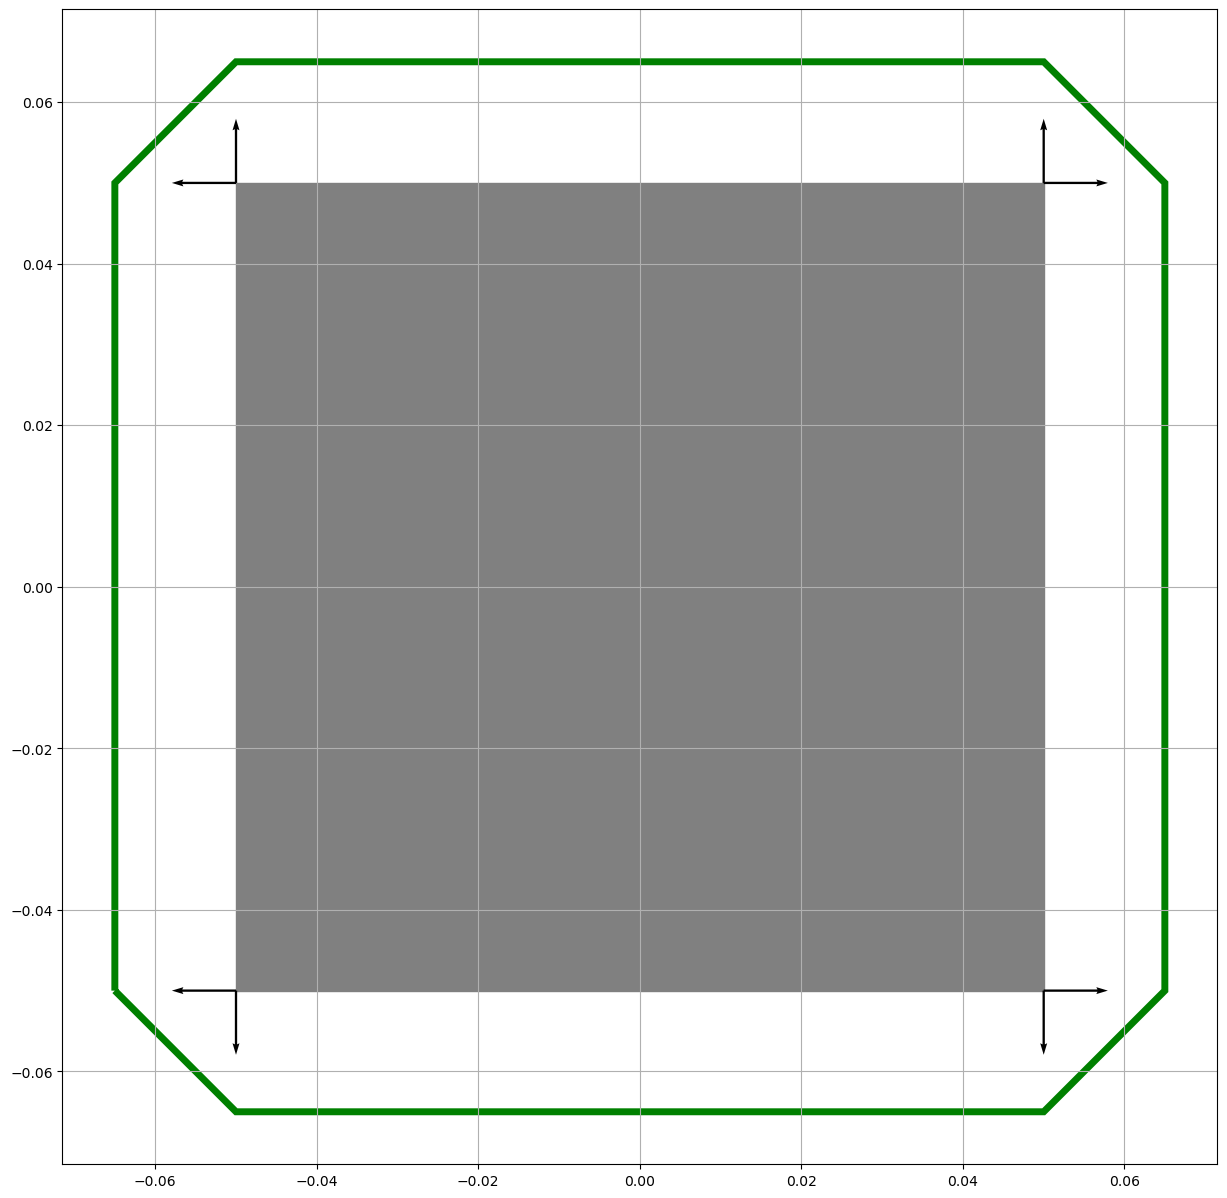

[180. -90. -90.   0.   0.  90.  90. 180.]


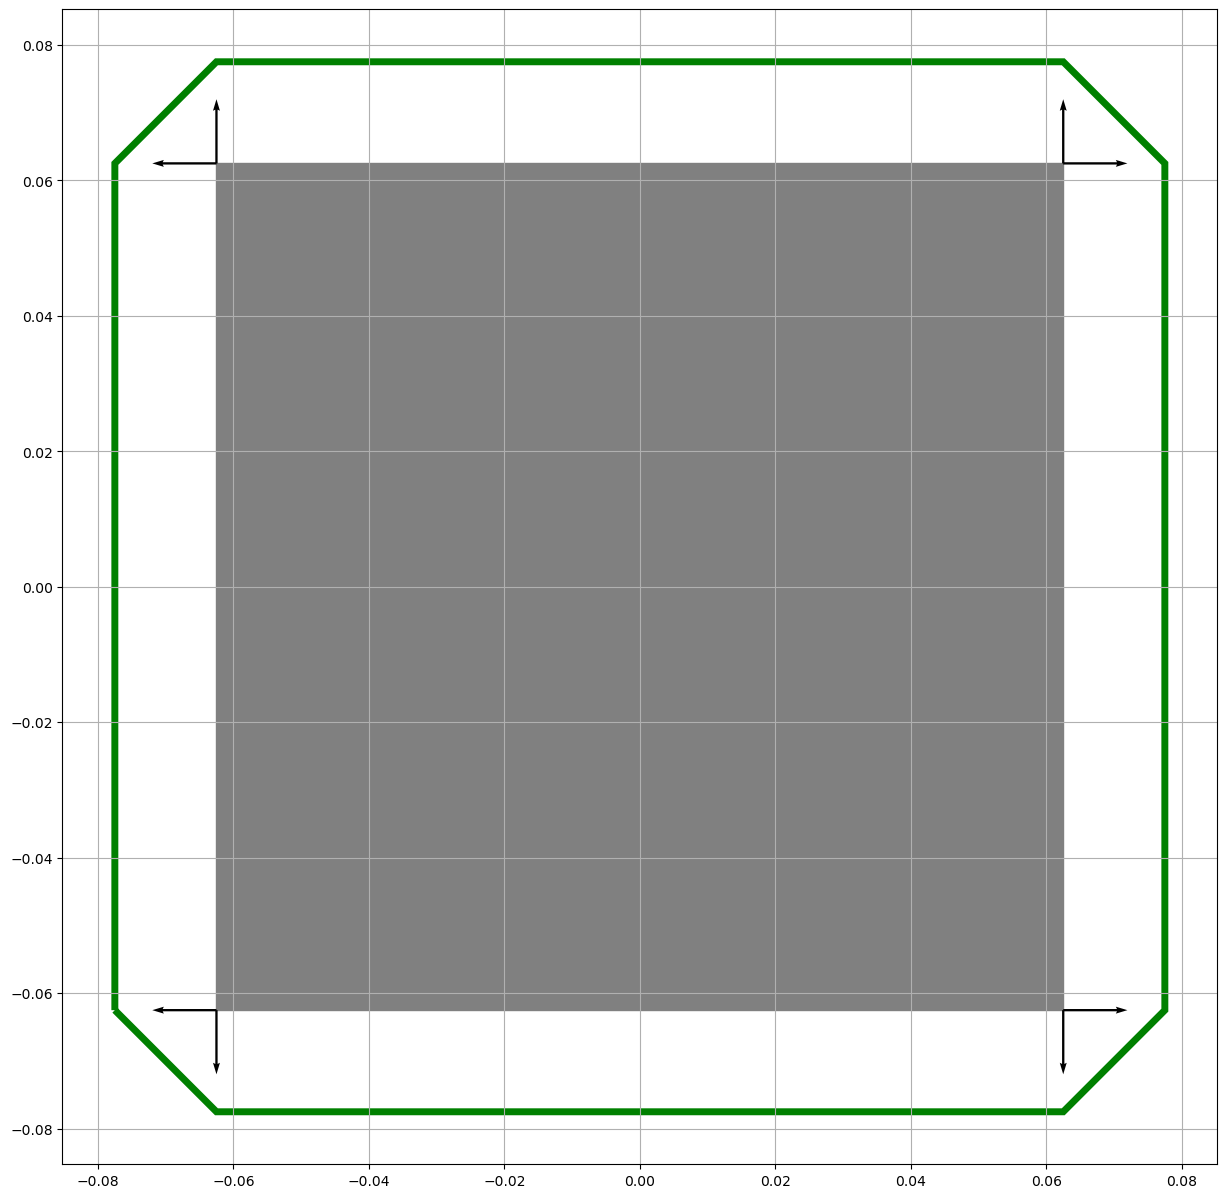

[180. -90. -90.   0.   0.  90.  90. 180.]


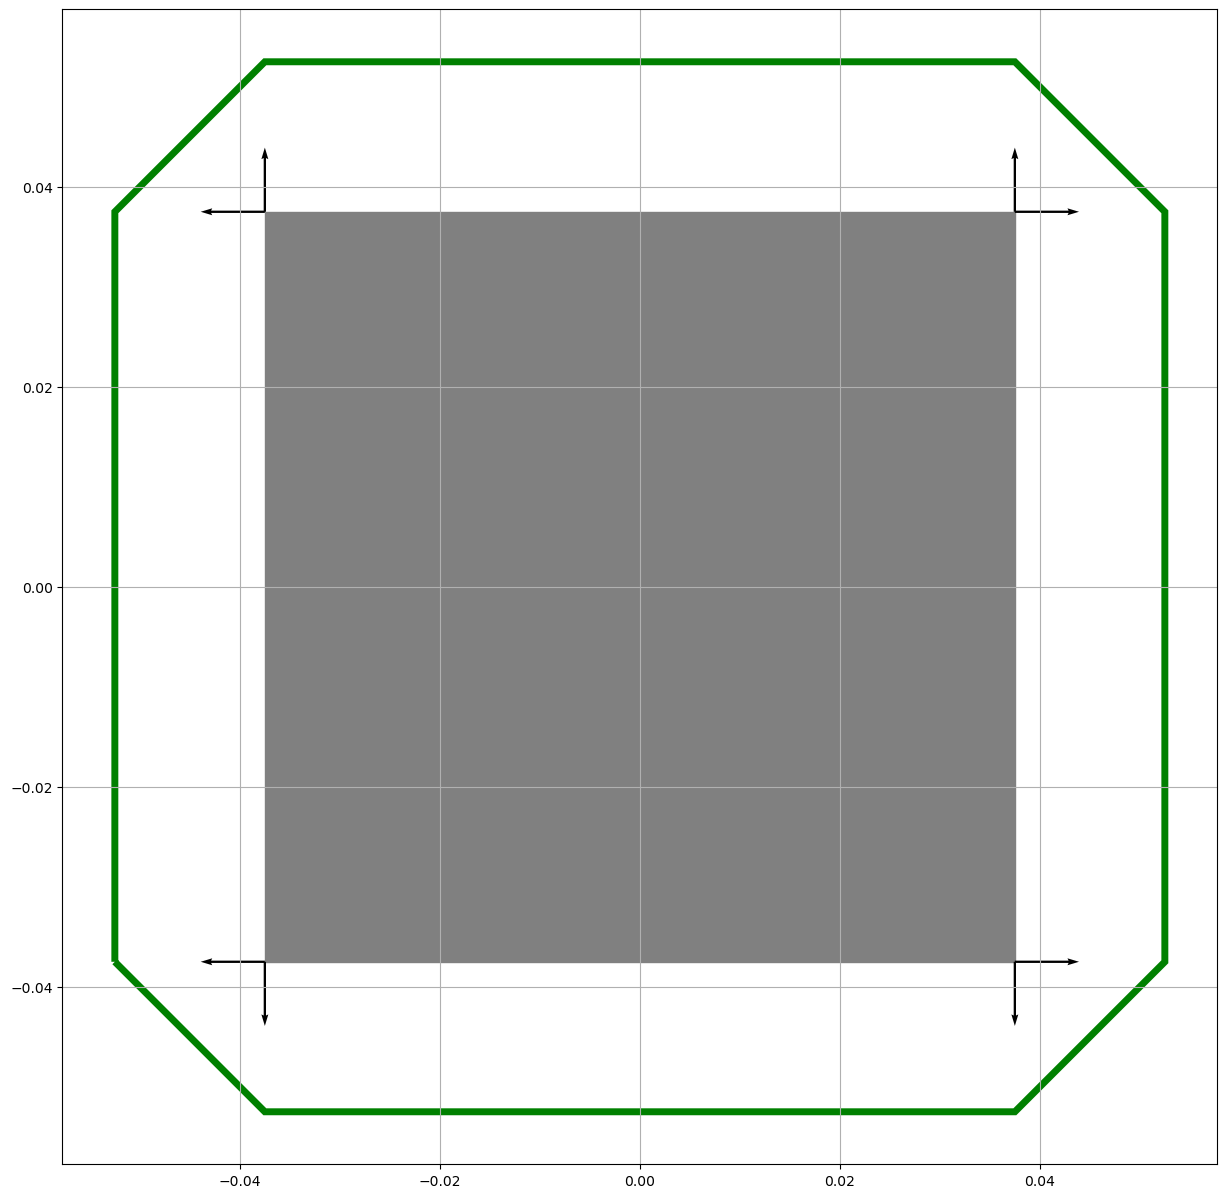

[180. -90. -90.   0.   0.  90.  90. 180.]


In [67]:
visualize_mesh = False
visualize_polygon = True
save_mesh = False
save_data = True
convert_usd = False
for mesh in meshes[-3:]:
    body_mesh = mesh.geometry["body"] if "body" in mesh.geometry else mesh.geometry["pillar"]

    # Assume there are two z values.
    lower_z = np.unique(body_mesh.vertices[:,2].round(decimals=6))[0]
    lower_vertices_mask = np.abs(body_mesh.vertices[:,2] - lower_z) < 1e-6
    lower_vertices = body_mesh.vertices[lower_vertices_mask]
    lower_normals = body_mesh.vertex_normals[lower_vertices_mask]

    xy_dist = np.linalg.norm(lower_vertices[:,:2], axis=1)
    xy_dist_unique = np.unique(xy_dist.round(decimals=6))
    if np.diff(xy_dist_unique).max() > 0.001:
        outer_xy_dist = np.unique(xy_dist.round(decimals=6))[-1]
        lower_outer_vertices_mask = np.abs(xy_dist - outer_xy_dist) < 1e-6
        lower_outer_vertices = lower_vertices[lower_outer_vertices_mask]
        lower_outer_normals = lower_normals[lower_outer_vertices_mask]
    else:
        lower_outer_vertices = lower_vertices
        lower_outer_normals = lower_normals
    lower_outer_normals[:,2] = 0.0
    lower_outer_normals = lower_outer_normals / np.linalg.norm(lower_outer_normals, axis=1, keepdims=True)

    if "Rect_Plate" in mesh.source.file_name:
        lower_outer_vertices = lower_outer_vertices.repeat(2, axis=0)
        lower_outer_normals = lower_outer_normals.repeat(2,axis=0)
        lower_outer_normals[(1,2,5,6),0] = 0.0
        lower_outer_normals[(0,3,4,7),1] = 0.0
        lower_outer_normals = lower_outer_normals / np.linalg.norm(lower_outer_normals, axis=1, keepdims=True)
    
    if visualize_mesh:
        vec = np.column_stack((lower_outer_vertices, lower_outer_vertices + (lower_outer_normals * body_mesh.scale * .05)))
        path = trimesh.load_path(vec.reshape((-1, 2, 3)))
        trimesh.Scene([body_mesh, path]).show("gl")

    if visualize_polygon:
        plt.figure(figsize=(15,15))
        eetrack_vertices = lower_outer_vertices + 0.015 * lower_outer_normals
        polygon = shapely.Polygon(lower_outer_vertices[:,:2])
        eetrack_polygon = shapely.Polygon(eetrack_vertices[:,:2])
        shapely.plotting.plot_polygon(polygon, add_points=False, facecolor='gray', edgecolor='gray')
        shapely.plotting.plot_polygon(eetrack_polygon, add_points=False, facecolor='none', edgecolor='green', linewidth=5.0)
        plt.quiver(lower_outer_vertices[:,0], lower_outer_vertices[:,1], lower_outer_normals[:,0], lower_outer_normals[:,1], width=0.002)
        plt.show()
        degs = np.arctan2(lower_outer_normals[:,1], lower_outer_normals[:,0])/np.pi*180
        print(degs[:66])

    if save_mesh:
        path_mesh_name = list(mesh.geometry.keys())[-1]
        mesh.delete_geometry(path_mesh_name)
        save_path = mesh.source.file_path.replace(os.path.splitext(mesh.source.file_path)[1], "_transformed.obj")
        mesh.export(save_path)

    if save_data:
        save_path = mesh.source.file_path.replace(os.path.splitext(mesh.source.file_path)[1], ".npz").replace("meshes", "edges")
        data = {
            "vertices": lower_outer_vertices,
            "normals": lower_outer_normals,
        }
        np.savez(save_path, **data)

    if convert_usd:
        transformed_mesh_path = mesh.source.file_path.replace(os.path.splitext(mesh.source.file_path)[1], "_transformed.obj")
        object_name = os.path.splitext(os.path.basename(mesh.source.file_path))[0]
        args = [
            "../isaaclab.sh",
            "-p",
            "../source/standalone/tools/convert_mesh.py",
            transformed_mesh_path,
            f"../source/extensions/omni.isaac.lab_assets/data/weld_objects/{object_name}/{object_name}.usd",
            "--collision-approximation", "meshSimplification", # "convexDecomposition",
            "--mass", "1.0",
            "--headless",
        ]
        subprocess.run(args)

In [ ]:
plt.figure(figsize=(15,15))
degs = np.arctan2(lower_outer_vertices[:,1], lower_outer_vertices[:,0])/np.pi*180
polygon = shapely.Polygon(lower_outer_vertices[:150,:2])
eetrack_polygon = shapely.Polygon(eetrack_vertices[:,:2])
shapely.plotting.plot_polygon(polygon, add_points=False, facecolor='gray', edgecolor='gray')
shapely.plotting.plot_polygon(eetrack_polygon, add_points=False, facecolor='none', edgecolor='green', linewidth=5.0)
plt.quiver(lower_outer_vertices[:,0], lower_outer_vertices[:,1], lower_outer_normals[:,0], lower_outer_normals[:,1], width=0.002)
plt.show()

In [ ]:
degs[:66]

In [ ]:
lower_outer_vertices.shape[0]/4

In [ ]:
os.path.splitext(os.path.basename(mesh.source.file_path))[0]

In [ ]:
meshes[0].source.file_path

In [ ]:
key = [key if "geometry_" in key else None for key in meshes[4].geometry.keys()]
key

In [ ]:
save_path

In [ ]:
import open3d as o3d

meshes_o3d: list[o3d.geometry.TriangleMesh] = [o3d.io.read_triangle_mesh(mesh_path) for mesh_path in mesh_path_list]
for mesh_o3d in meshes_o3d: mesh_o3d.rotate(R.from_euler('x', 90, degrees=True).as_matrix(), center=[0,0,0])
for mesh_o3d in meshes_o3d: mesh_o3d.scale(0.001, center=[0,0,0])

In [ ]:
import torch
from pathlib import Path
import pandas as pd

# rsync -avzr im_server:/home/grasp/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/2025-06-23-19-09-32/ /home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/2025-06-23-19-09-32/

best_base_pose_data_path_list = Path("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/2025-06-23-19-09-32").rglob("best_base_pose.pt")

summary_dict = {
    "weld_object_type": [],
    "segment_degs": [],
    "success_rate": [],
    "num_success": [],
    "num_total": [],
    "x": [],
    "y": [],
    "yaw": [],
    "dxy": [],
    "dyaw": [],
}

for path in best_base_pose_data_path_list:
    data = torch.load(path, "cpu")
    summary_dict["weld_object_type"].append(path.as_posix().split("weld_object_type_")[1].split("_weld_object_z")[0])
    summary_dict["segment_degs"].append(path.parent.as_posix().split("segment_degs_")[1])
    summary_dict["success_rate"].append(data['success_rate'])
    summary_dict["num_success"].append(data['num_success'].item())
    summary_dict["num_total"].append(data['num_total'].item())
    summary_dict["x"].append(data['xyyaw'][0])
    summary_dict["y"].append(data['xyyaw'][1])
    summary_dict["yaw"].append(data['xyyaw'][2])
    summary_dict["dxy"].append(data['dxy'])
    summary_dict["dyaw"].append(data['dyaw'])
summary_pd = pd.DataFrame(summary_dict)
summary_pd

In [ ]:
pd.set_option("display.max_rows", 150)
summary_pd.sort_values(["weld_object_type", "success_rate", "num_success"], ascending=False, ignore_index=True)

In [ ]:
subpd = summary_pd[summary_pd["weld_object_type"]=="Circular_Body_Plate_110_80"]
subpd.sort_values(["success_rate", "num_success"], ascending=False, ignore_index=True)

In [ ]:
subpd = summary_pd[summary_pd["weld_object_type"]=="Circular_Body_Plate_80_50"]
subpd.sort_values(["success_rate", "num_success"], ascending=False, ignore_index=True)

In [ ]:
try:
    import abcd
except ImportError as e:
    print(e)
import abcd


In [ ]:
import pstats

stats = pstats.Stats("../profile1.prof")

In [ ]:
total_time_for_percentage = stats.total_tt # 전체 tottime 합계

# 결과를 저장할 리스트
formatted_results = []
for func_name, (cc, nc, tt, ct, callers) in stats.stats.items():
    if total_time_for_percentage > 0:
        percentage = (tt / total_time_for_percentage) * 100
    else:
        percentage = 0.0
    
    formatted_results.append({
        'func': func_name,
        'tottime_sec': tt, # 함수 자체 시간
        'cumtime_sec': ct, # 누적 시간
        'percentage': percentage
    })

# 비율 기준으로 내림차순 정렬 (혹은 원하는 정렬 기준)
formatted_results.sort(key=lambda x: x['percentage'], reverse=True)

# 출력
print(f"{'func':<60} {'time (sec)':>15} {'ratio (%)':>10}")# {'cumtime (sec)':>15}")
print("-" * 95)

for item in formatted_results[:20]:
    print(f"{':'.join(map(str, item['func'])):<60.60} {item['tottime_sec']:>15.4f} {item['percentage']:>10.1f}")# {item['cumtime_sec']:>15.4f}")

print("-" * 95)
print(f"{'Total':<60} {total_time_for_percentage:>15.4f} {100.0:>10.1f}")# {total_time_for_percentage:>15.4f}")

In [ ]:
sum(map(lambda x: x["percentage"], formatted_results))

In [ ]:
import torch
from pprint import pprint

data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/manual/seed_42_weld_object_type_Circular_Body_Plate_80_50_meshsimp_weld_object_z_0.40_0.40_x_-0.65_-0.35_y_-0.10_0.20_yaw_0.00_1.75_h_0.44_0.44_segment_degs_-89.00_-1.00_appr_deg_45.0/best_base_pose.pt")
pprint(data)

In [ ]:
import torch
import numpy as np
from pprint import pprint

data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/manual/seed_42_weld_object_type_Circular_Body_Plate_80_50_weld_object_z_0.40_0.40_x_-0.60_-0.20_y_-0.15_0.25_yaw_-0.35_1.75_h_0.45_0.45_segment_degs_-89.00_-1.00_appr_deg_45.0/best_base_pose.pt")
data["xyyaws"] = np.round(data["xyyaws"], 7).tolist()
pprint(data)

In [ ]:
import trimesh
import numpy as np

welder_mesh = trimesh.load("../source/extensions/omni.isaac.lab_assets/data/g1_UDRF/meshes/welder_HG200.STL")
# welder_mesh.scene().show("gl")
vert1 = (welder_mesh.vertices[:,2] <= 0.11).nonzero()[0]
vert2 = (welder_mesh.vertices[:,2] > 0.11).nonzero()[0]
face1 = np.all(np.isin(welder_mesh.faces, vert1), axis=1)
face2 = np.all(np.isin(welder_mesh.faces, vert2), axis=1)

new_faces1 = welder_mesh.faces[face1]
unique_vert1, inverse_ids1 = np.unique(welder_mesh.vertices[vert1], axis=0, return_inverse=True)
new_faces1 = inverse_ids1[np.searchsorted(vert1, new_faces1)]

new_faces2 = welder_mesh.faces[face2]
unique_vert2, inverse_ids2 = np.unique(welder_mesh.vertices[vert2], axis=0, return_inverse=True)
new_faces2 = inverse_ids2[np.searchsorted(vert2, new_faces2)]

mesh1 = trimesh.Trimesh(vertices=unique_vert1, faces=new_faces1)
mesh2 = trimesh.Trimesh(vertices=unique_vert2, faces=new_faces2)
trimesh.Scene([mesh1, mesh2]).show("gl")

In [ ]:
welder_mesh = trimesh.load("../source/extensions/omni.isaac.lab_assets/data/g1_UDRF/meshes/welder.STL")
welder_mesh.scene().show("gl")

In [ ]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

welder_mesh = trimesh.load("../source/extensions/omni.isaac.lab_assets/data/g1_UDRF/meshes/welder_HG200.STL")
plt.plot(welder_mesh.vertices[:,2])

In [ ]:
welder_mesh.scene().show("gl")

In [ ]:
mesh1.export("../source/extensions/omni.isaac.lab_assets/data/g1_UDRF/meshes/welder_HG200_submesh1.STL")
mesh2.export("../source/extensions/omni.isaac.lab_assets/data/g1_UDRF/meshes/welder_HG200_submesh2.STL")

In [ ]:
welder_mesh

In [ ]:
import matplotlib.pyplot as plt
plt.plot(welder_mesh.vertices[:,2])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
x = np.array([-0.6173469424247742, -0.62, -0.6, -0.5163265466690063, -0.4673469364643097])
y = np.array([0.013265341520309448, 0.06, -0.13, 0.06836731731891632, 0.0326530747115612])
yaw = np.array([0.7800553441047668, 0.6632251143455505, 1.3570826053619385, 1.1291213035583496, 1.0721309185028076])  # in radians
s = 22.5*np.array([750, 1000, 500, 1000, 500])
theta = np.array([30, 37.5, 45, 52.5, 60])

# Compute direction vectors for arrows
u = np.cos(yaw)
v = np.sin(yaw)

plt.figure(figsize=(10, 10))

# Plot circles at each (x, y)
plt.scatter(x, y, s=s, facecolors='none', edgecolors='blue', label='Pose (circle)')

# Plot yaw arrows from each point
plt.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=20, color='red', width=0.01)

for x_i, y_i, theta_i in zip(x, y, theta):
    plt.text(x_i, y_i, s=f"θ={theta_i}", ha='center', va='top', fontsize='large')

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.title('Sit base pose for approach angle in line segment')
# plt.legend()
plt.xlim([-0.75, -0.35])
plt.ylim([-0.2, 0.2])
plt.show()

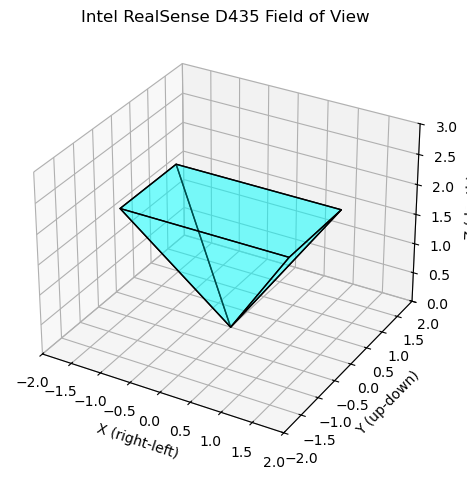

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# %matplotlib wx

# Camera FOV in degrees
h_fov = 69.4  # horizontal FOV
v_fov = 42.5  # vertical FOV
depth = 2.0  # max view distance in meters

# Convert FOV to radians
h_fov_rad = np.radians(h_fov)
v_fov_rad = np.radians(v_fov)

# Half angles
h_half = h_fov_rad / 2
v_half = v_fov_rad / 2

# Calculate frustum corners at 'depth' distance
x_right = depth * np.tan(h_half)
x_left = -x_right
y_top = depth * np.tan(v_half)
y_bottom = -y_top

# Camera origin
origin = np.array([0, 0, 0])

# Frustum corner points (z is depth)
corners = np.array([
    [x_left,  y_top,    depth],   # top-left
    [x_right, y_top,    depth],   # top-right
    [x_right, y_bottom, depth],   # bottom-right
    [x_left,  y_bottom, depth],   # bottom-left
])

# Create faces of the frustum
faces = [
    [origin, corners[0], corners[1]],  # top face
    [origin, corners[1], corners[2]],  # right face
    [origin, corners[2], corners[3]],  # bottom face
    [origin, corners[3], corners[0]],  # left face
    [corners[0], corners[1], corners[2], corners[3]]  # far plane
]

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

frustum = Poly3DCollection(faces, alpha=0.3, facecolors='cyan', edgecolors='black')
ax.add_collection3d(frustum)

# Axes labels and limits
ax.set_xlabel('X (right-left)')
ax.set_ylabel('Y (up-down)')
ax.set_zlabel('Z (depth)')
ax.set_xlim([-depth, depth])
ax.set_ylim([-depth, depth])
ax.set_zlim([0, depth*1.5])
ax.set_title('Intel RealSense D435 Field of View')

plt.tight_layout()
plt.show()

In [15]:
import trimesh
mesh = trimesh.load("/home/dulee/ws/humanoid_eetrack/source/extensions/omni.isaac.lab_assets/data/weld_objects/meshes/Rect_Body_Plate_145_125_transformed.obj")
mesh.show()

In [2]:
import torch

data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right_arm/terminal_states_52536.pt")
data

/tmp/ipykernel_3015159/3461528856.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("/home/dulee/ws/humanoid_eetrack/logs/rsl_rl/g1_eetrack/sitting_right

{'root_state': tensor([[ 3.6311e-04,  1.2514e-02,  7.0172e-01,  ..., -1.7414e-01,
          -5.1262e-02, -2.4933e-02],
         [ 1.5412e-02, -1.1726e-02,  7.0620e-01,  ...,  5.7392e-03,
          -3.6216e-03, -5.4057e-02],
         [-7.9422e-03,  7.7133e-03,  6.9264e-01,  ...,  1.2567e-02,
          -3.9820e-02, -4.6702e-02],
         ...,
         [ 7.8575e-02,  1.7669e-02,  4.6716e-01,  ...,  2.0938e-02,
           7.0138e-03,  5.4759e-02],
         [ 8.0282e-02,  5.0575e-02,  3.4605e-01,  ...,  7.5715e-02,
           1.3138e-02, -1.0747e-01],
         [-4.2856e-02, -9.6207e-03,  4.2629e-01,  ..., -5.6412e-02,
           1.6041e-02,  1.1633e-02]], device='cuda:0'),
 'joint_state': tensor([[[-6.1983e-01, -4.7425e-01, -2.3142e-02,  ..., -1.3054e-02,
            6.6479e-03,  3.2545e-03],
          [-3.2466e-01, -2.7646e-01,  4.8989e-02,  ...,  1.9363e-02,
            3.6727e-02, -1.4446e-02]],
 
         [[-5.7204e-01, -4.8720e-01, -1.9757e-02,  ..., -9.7352e-04,
            7.3667e-03